In [12]:
import pandas as pd
import numpy as np

prices = pd.read_csv("../data/raw/prices_raw.csv")
market_dataset = pd.read_csv("../data/processed/market_dataset.csv")

prices["timestamp"] = pd.to_datetime(prices["timestamp"])

In [13]:
prices.head()


,timestamp,implied_probability,market_id,question,slug
0,2023-02-07 01:00:32+00:00,0.5,248594,Will Hunter Biden be federally indicted by May...,will-hunter-biden-be-federally-indicted-by-may...
1,2023-02-07 02:00:53+00:00,0.5,248594,Will Hunter Biden be federally indicted by May...,will-hunter-biden-be-federally-indicted-by-may...
2,2023-02-07 03:00:34+00:00,0.5,248594,Will Hunter Biden be federally indicted by May...,will-hunter-biden-be-federally-indicted-by-may...
3,2023-02-07 04:00:05+00:00,0.5,248594,Will Hunter Biden be federally indicted by May...,will-hunter-biden-be-federally-indicted-by-may...
4,2023-02-07 05:00:07+00:00,0.5,248594,Will Hunter Biden be federally indicted by May...,will-hunter-biden-be-federally-indicted-by-may...


In [6]:
prices["market_id"].nunique()

43

In [8]:
from scipy.stats import linregress
prices = prices.sort_values(["market_id","timestamp"])
prices["prob_return"] = (prices.groupby("market_id")["implied_probability"].diff())
prices = prices.sort_values(["market_id","timestamp"])
rv = (prices.groupby("market_id")["prob_return"].apply(lambda x: np.sum(x.dropna()**2)))
prob_range = (prices.groupby("market_id")["implied_probability"].agg(lambda x: x.max()-x.min()))
def compute_trend(series):
    y = series.values
    x = np.arange(len(y))
    beta = linregress(x,y).slope
    return beta

def max_drawdown(series):
    running_max = np.maximum.accumulate(series)
    drawdown = (running_max - series) / running_max
    return np.max(drawdown)

def count_reversals(returns):
    signs = np.sign(returns.dropna())
    return np.sum(signs.diff().fillna(0)!=0)

trend = (prices.groupby("market_id")["implied_probability"].apply(compute_trend).rename("trend"))
mdd = (prices.groupby("market_id")["implied_probability"].apply(max_drawdown).rename("max_drawdown"))
reversals = (prices.groupby("market_id")["prob_return"].apply(count_reversals).rename("reversals"))
rv = rv.rename("realized_volatility")
prob_range = prob_range.rename("probability_range")
market_features = pd.concat([rv, prob_range,trend,mdd,reversals],axis=1).reset_index()

In [10]:
market_features.describe().T
market_features.to_csv('../data/processed/market_features.csv', index = False)

In [14]:
df_model = market_dataset.merge(market_features,on="market_id",how="left")

In [15]:
df_model["abs_surprise"] = (df_model["outcome"]- df_model["final_probability"]).abs()

In [16]:
features = [
    "realized_volatility",
    "probability_range",
    "trend",
    "max_drawdown",
    "reversals"
]

df_model[
    features + ["abs_surprise"]
].corr()["abs_surprise"].sort_values()

max_drawdown          -0.755926
probability_range     -0.587153
reversals             -0.370240
realized_volatility   -0.143927
trend                 -0.078924
abs_surprise           1.000000
Name: abs_surprise, dtype: float64

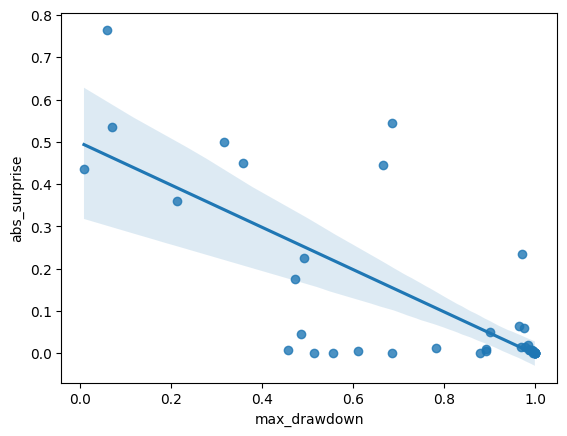

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.regplot(
    data=df_model,
    x="max_drawdown",
    y="abs_surprise"
)
plt.show()

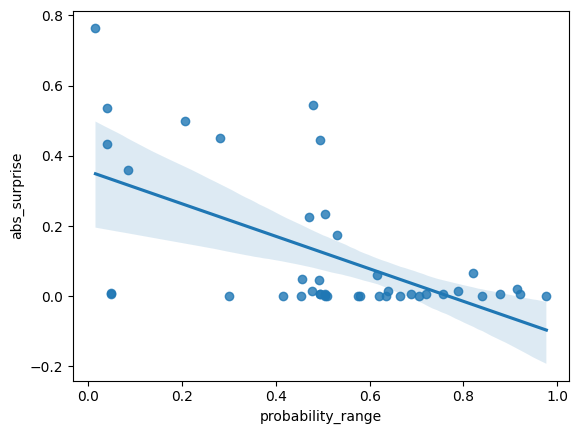

In [18]:
sns.regplot(
    data=df_model,
    x="probability_range",
    y="abs_surprise"
)
plt.show()

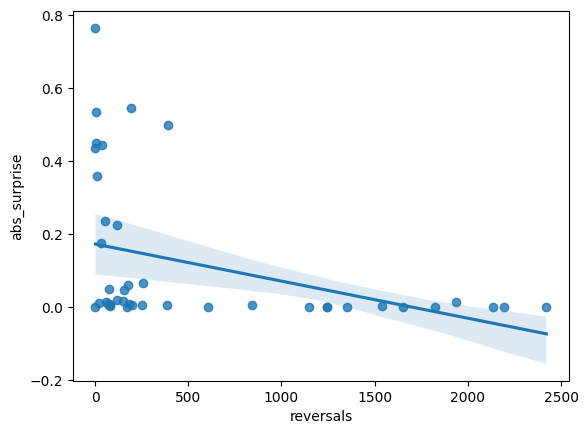

In [19]:
sns.regplot(
    data=df_model,
    x="reversals",
    y="abs_surprise"
)
plt.show()

In [20]:
import statsmodels.api as sm

X = df_model[
    [
        "max_drawdown",
        "probability_range",
        "reversals"
    ]
]

X = sm.add_constant(X)

y = df_model["abs_surprise"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           abs_surprise   R-squared:                       0.624
Model:                            OLS   Adj. R-squared:                  0.596
Method:                 Least Squares   F-statistic:                     21.61
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           2.07e-08
Time:                        04:18:44   Log-Likelihood:                 29.511
No. Observations:                  43   AIC:                            -51.02
Df Residuals:                      39   BIC:                            -43.98
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.5265      0.05

Prediction market efficiency appears to be strongly associated with the magnitude of probability revisions over the market lifetime.

In [21]:
X = df_model[
    [
        "max_drawdown",
        "probability_range"
    ]
]

X = sm.add_constant(X)

model = sm.OLS(
    df_model["abs_surprise"],
    X
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           abs_surprise   R-squared:                       0.614
Model:                            OLS   Adj. R-squared:                  0.595
Method:                 Least Squares   F-statistic:                     31.81
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           5.41e-09
Time:                        04:21:02   Log-Likelihood:                 28.921
No. Observations:                  43   AIC:                            -51.84
Df Residuals:                      40   BIC:                            -46.56
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.5301      0.05

In [22]:
df_model.to_csv('../data/processed/df_model.csv', index = False )